In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [83]:
df = pd.read_csv('stud.csv')

In [84]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [85]:
df.shape

(1000, 8)

In [17]:
# Check for missing values
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [18]:
#Check for duplicates
df.duplicated().sum()

0

In [20]:
# Check for data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [21]:
# checking for unique values in each column
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [22]:
#Check for statistical summary of the dataset
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [23]:
# Exploring Data
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [25]:
# Check for unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'gender': ['female' 'male']
Unique values in 'race_ethnicity': ['group B' 'group C' 'group A' 'group D' 'group E']
Unique values in 'parental_level_of_education': ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Unique values in 'lunch': ['standard' 'free/reduced']
Unique values in 'test_preparation_course': ['none' 'completed']


In [27]:
# define numerical and categorical columns
numeric_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features =df.select_dtypes(include=['object']).columns

# print columns names
print('We have {} numeric features : {}'.format(len(numeric_features),numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features),categorical_features))    



We have 3 numeric features : Index(['math_score', 'reading_score', 'writing_score'], dtype='object')
We have 5 categorical features : Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')


In [28]:
df.head(2)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [30]:
# Adding total score and average score columns
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333,76.333333


In [32]:
reading_full = (df['reading_score']==100).sum()
writing_full = (df['writing_score']==100).sum()
math_full = (df['math_score']==100).sum()

print(f"Number of students with full score in reading: {reading_full}")
print(f"Number of students with full score in writing: {writing_full}")
print(f"Number of students with full score in math: {math_full}")

Number of students with full score in reading: 17
Number of students with full score in writing: 14
Number of students with full score in math: 7


In [34]:
reading_less_20 = (df['reading_score']<=20).sum()
writing_less_20 = (df['writing_score']<=20).sum()
math_less_20 = (df['math_score']<=20).sum()

print(f"Number of students with score less than 20 in reading: {reading_less_20}")
print(f"Number of students with score less than 20 in writing: {writing_less_20}")
print(f"Number of students with score less than 20 in math: {math_less_20}")

Number of students with score less than 20 in reading: 1
Number of students with score less than 20 in writing: 3
Number of students with score less than 20 in math: 4


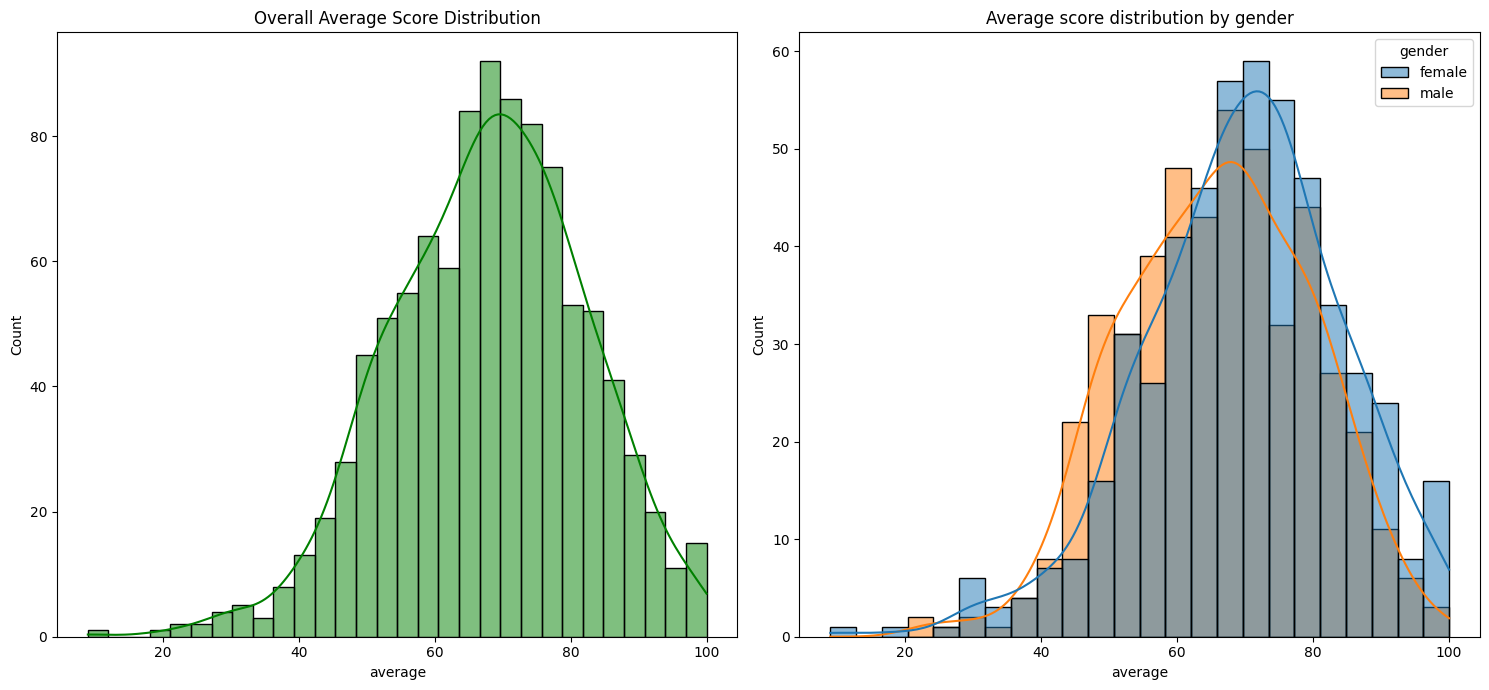

In [40]:
# Exploring the data (Vizualization)

fig, axs = plt.subplots(1,2,figsize=(15,7))
sns.histplot(data=df,x='average',bins=30,kde=True,color='g',ax=axs[0])
axs[0].set_title("Overall Average Score Distribution")


sns.histplot(data=df,x='average',kde=True,hue='gender',ax=axs[1])
axs[1].set_title("Average score distribution by gender")

plt.tight_layout()
plt.show()

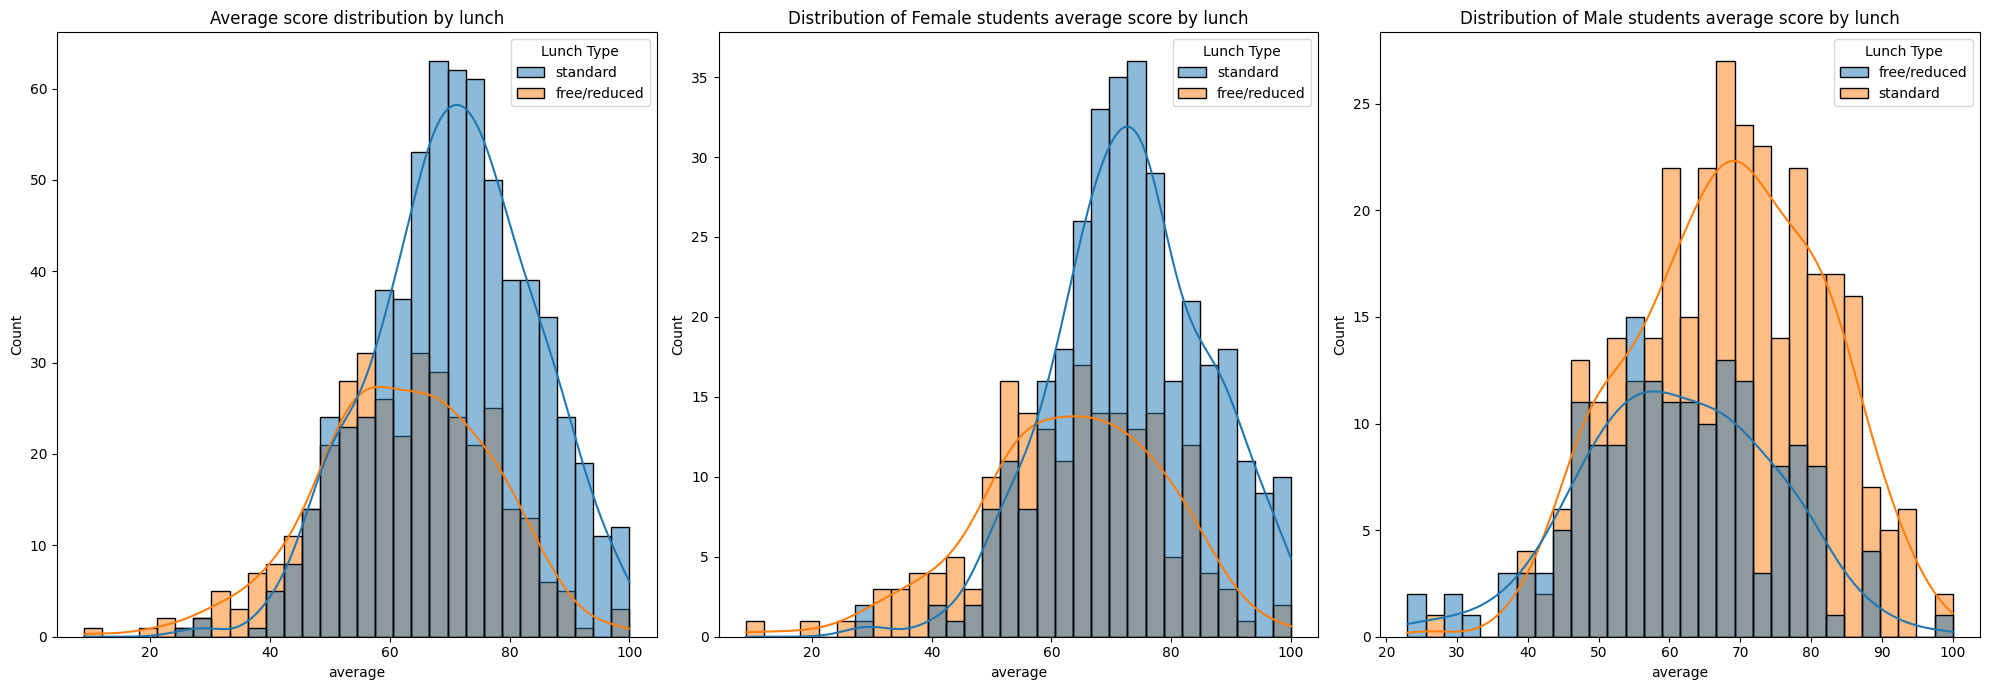

In [55]:
# Renaming the column name used here in hue for better viszualization.

df = df.rename(columns = {'lunch': 'Lunch Type'})

# Create an Histogram of average score by lunch type.
fig,axs= plt.subplots(1,3,figsize = (20,7))

sns.histplot(data=df,x='average',bins=30,kde=True,hue='Lunch Type',ax=axs[0])
axs[0].set_title("Average score distribution by lunch")

sns.histplot(data=df[df.gender=='female'],x= 'average', bins = 30, kde = True, hue = 'Lunch Type', ax=axs[1])
axs[1].set_title("Distribution of Female students average score by lunch")

sns.histplot(data=df[df.gender=='male'],x='average',kde = True, bins = 30, hue = 'Lunch Type', ax=axs[2])
axs[2].set_title("Distribution of Male students average score by lunch")

plt.tight_layout()
plt.show()

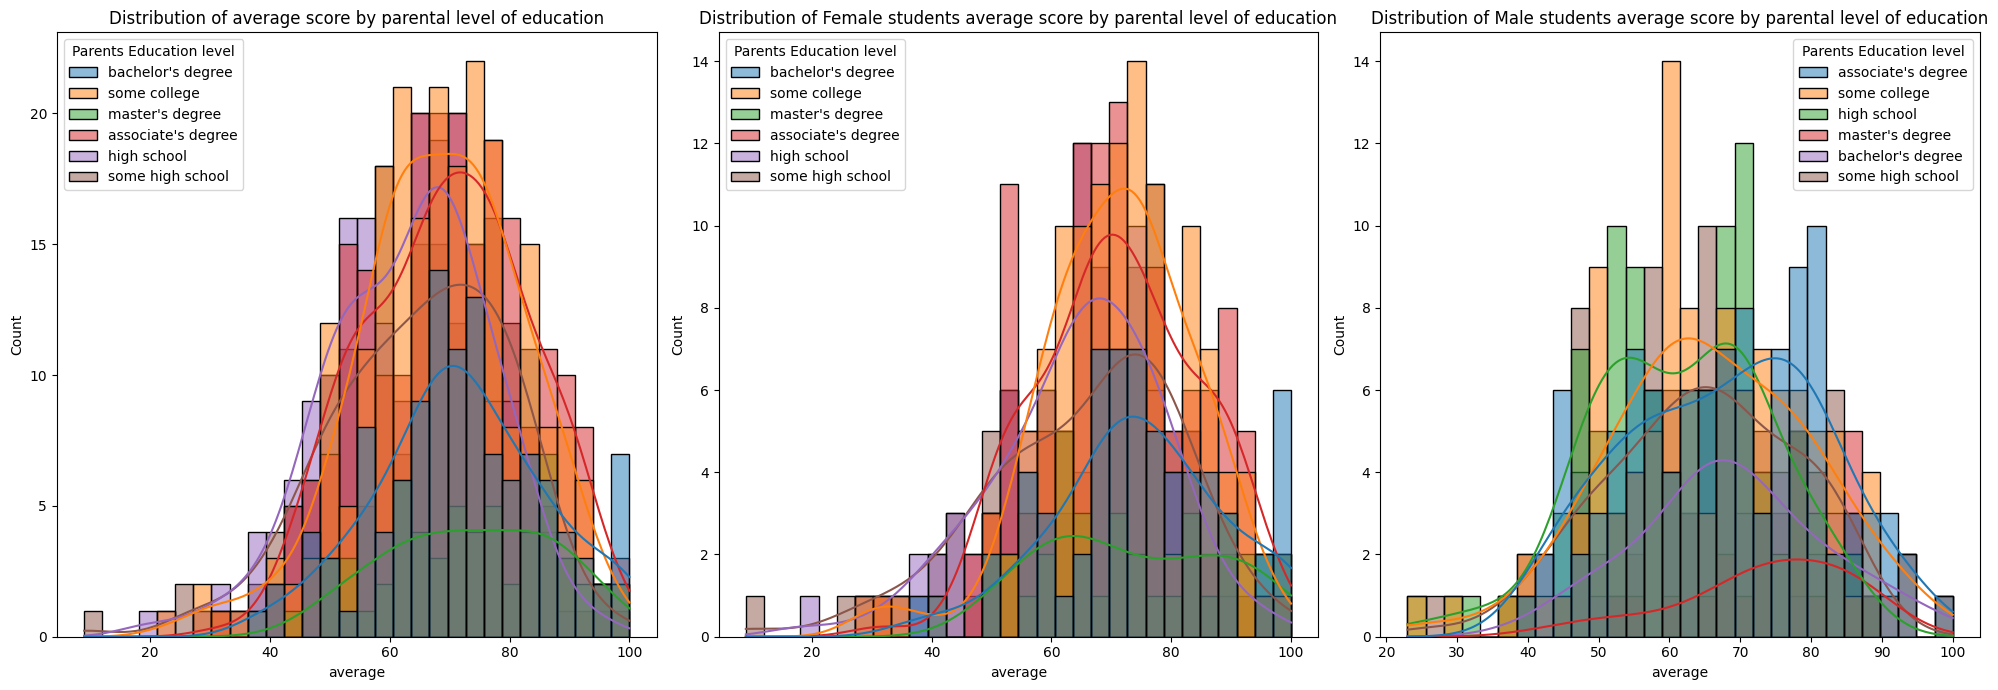

In [53]:
# Rename the column name used here in HUE for better Legend in the plot. AS we have multiple plots created, plt.legend() cannot be used.

df = df.rename(columns={'parental_level_of_education': 'Parents Education level'})

# Histogram of average score by parental level of education

fig,axs = plt.subplots (1,3,figsize = (20,7))

sns.histplot(data = df, x = 'average', bins = 30, kde = True, hue = 'Parents Education level', ax = axs[0])
axs[0].set_title("Distribution of average score by parental level of education")

sns.histplot(data = df[df.gender=='female'],x = 'average', bins = 30, kde = True, hue = 'Parents Education level', ax = axs[1])
axs[1].set_title ("Distribution of Female students average score by parental level of education")

sns.histplot(data = df[df.gender=='male'],x = 'average', bins = 30, kde = True, hue = 'Parents Education level', ax = axs[2])
axs[2].set_title ("Distribution of Male students average score by parental level of education")
plt.tight_layout()
plt.show()  

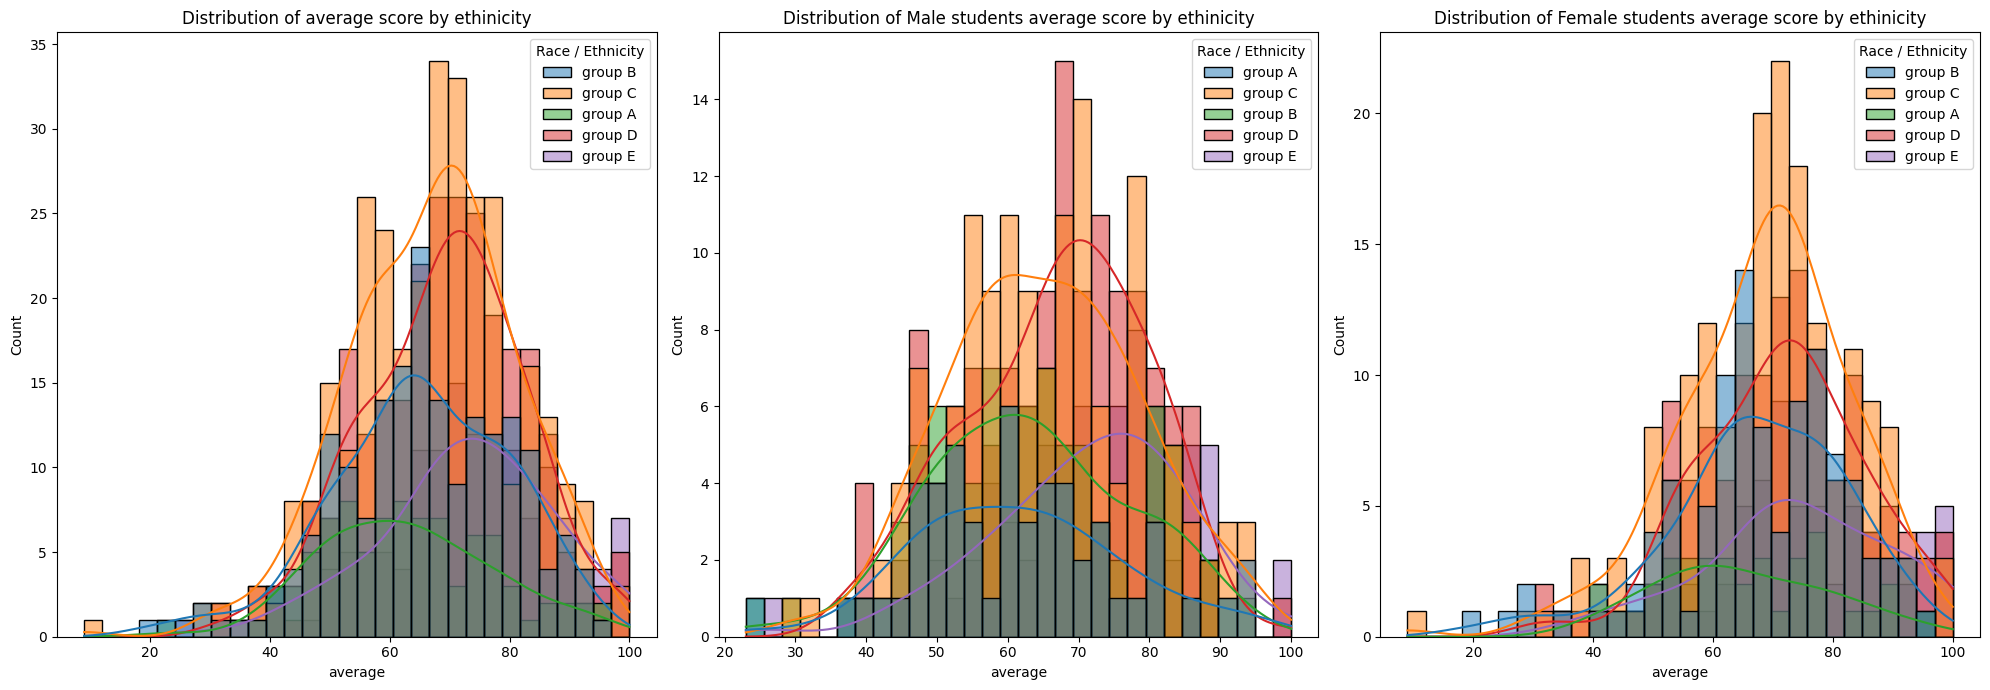

In [ ]:
df = df.rename(columns={'race_ethnicity': 'Race / Ethnicity'})


#Histogram of average score based by ethinicity

fig, axs = plt.subplots(1,3,figsize=(20,7))

sns.histplot(data = df, x = 'average', bins = 30, kde = True, hue = 'Race / Ethnicity', ax = axs[0])
axs[0].set_title("Distribution of average score by ethinicity")

sns.histplot (data = df[df.gender == 'male'], x = 'average',bins = 30, kde=True, hue = 'Race / Ethnicity', ax = axs[1])
axs[1].set_title("Distribution of Male students average score by ethinicity")

sns.histplot (data =df[df.gender == 'female'], x = 'average',bins = 30, kde= True, hue = 'Race / Ethnicity', ax = axs[2])
axs[2].set_title("Distribution of Female students average score by ethinicity")

plt.tight_layout()
plt.show()

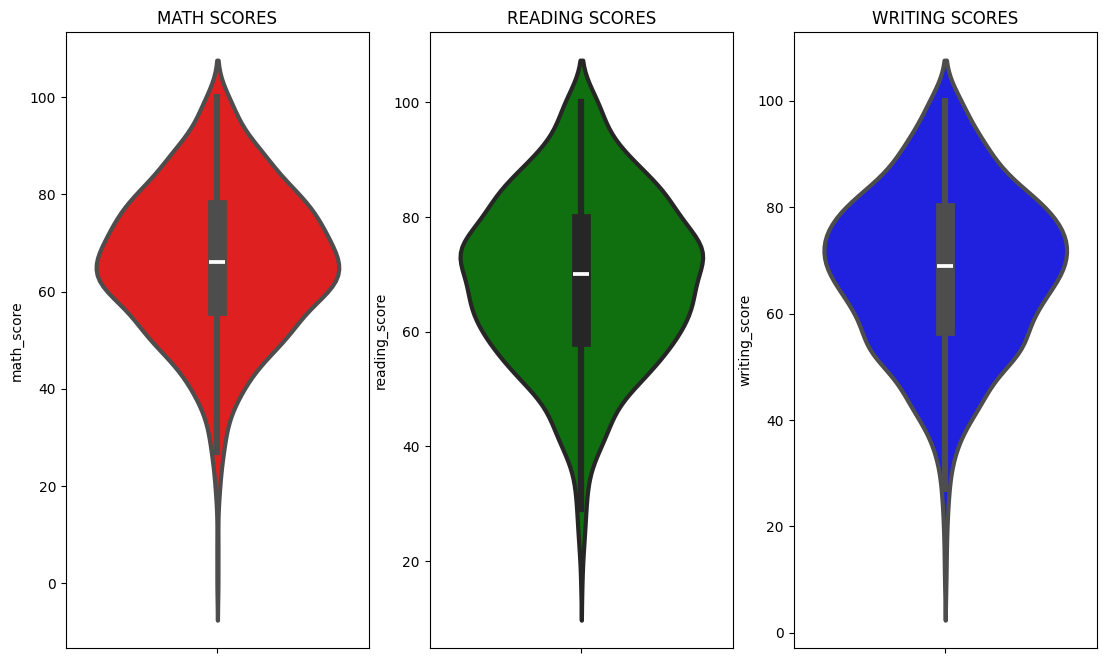

In [58]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

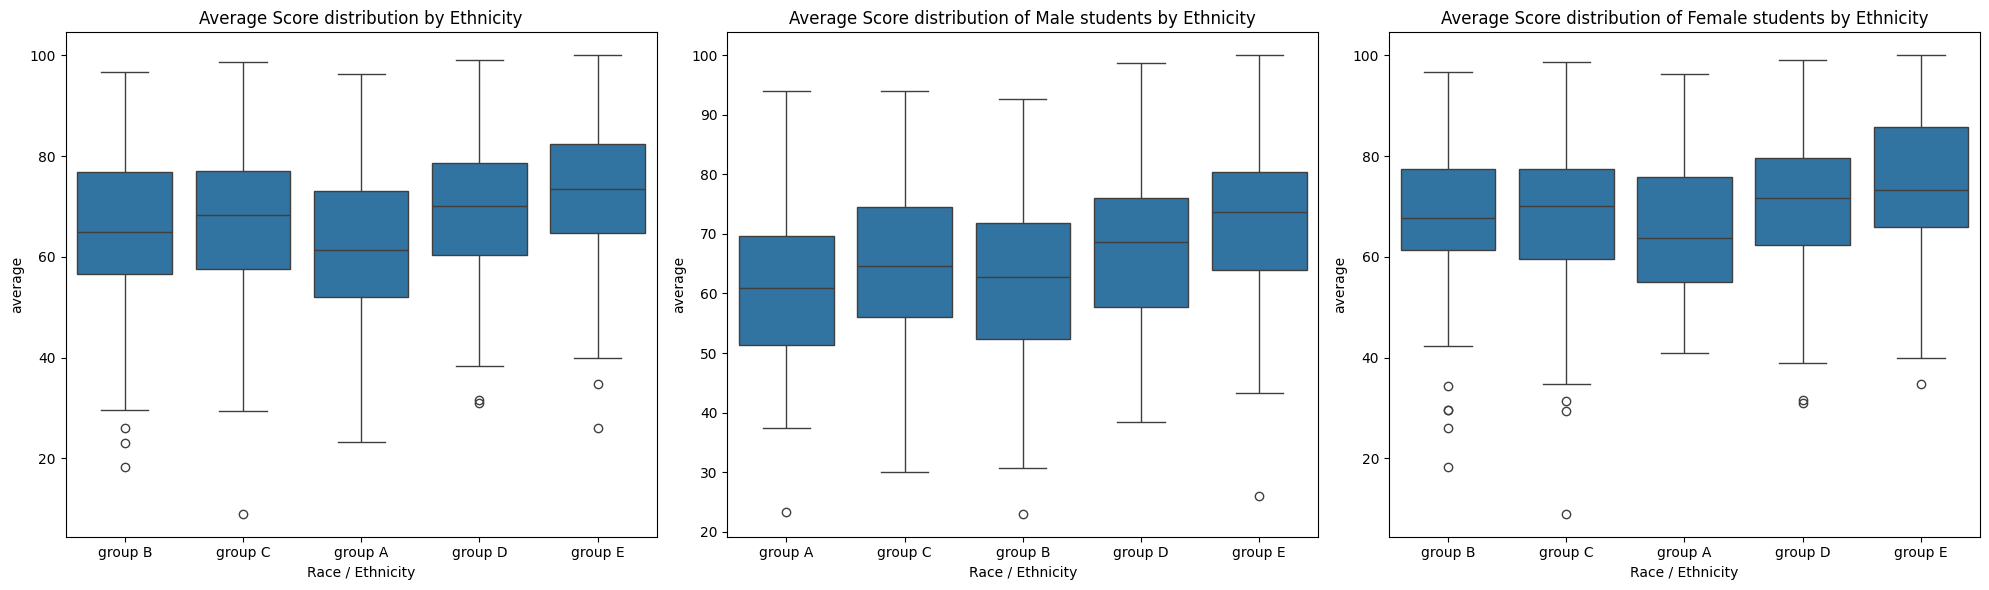

In [65]:
# Now we will built a box-plot to check for outliers in the data.

fig, axs = plt.subplots(1,3,figsize=(20,6))

#Overall average score distribution by ethnicity : 

sns.boxplot(data = df, x = 'Race / Ethnicity', y= 'average', ax=axs[0])
axs[0].set_title("Average Score distribution by Ethnicity")

# Male students average score distribution by ethnicity

sns.boxplot(data = df[df.gender == 'male'], x = 'Race / Ethnicity' , y = 'average', ax = axs[1])
axs[1].set_title("Average Score distribution of Male students by Ethnicity")

# Female students average score distribution by ethinicity.

sns.boxplot(data = df[df.gender == 'female'], x = 'Race / Ethnicity', y = 'average', ax = axs[2])
axs[2].set_title("Average Score distribution of Female students by Ethnicity")

plt.tight_layout()
plt.show()

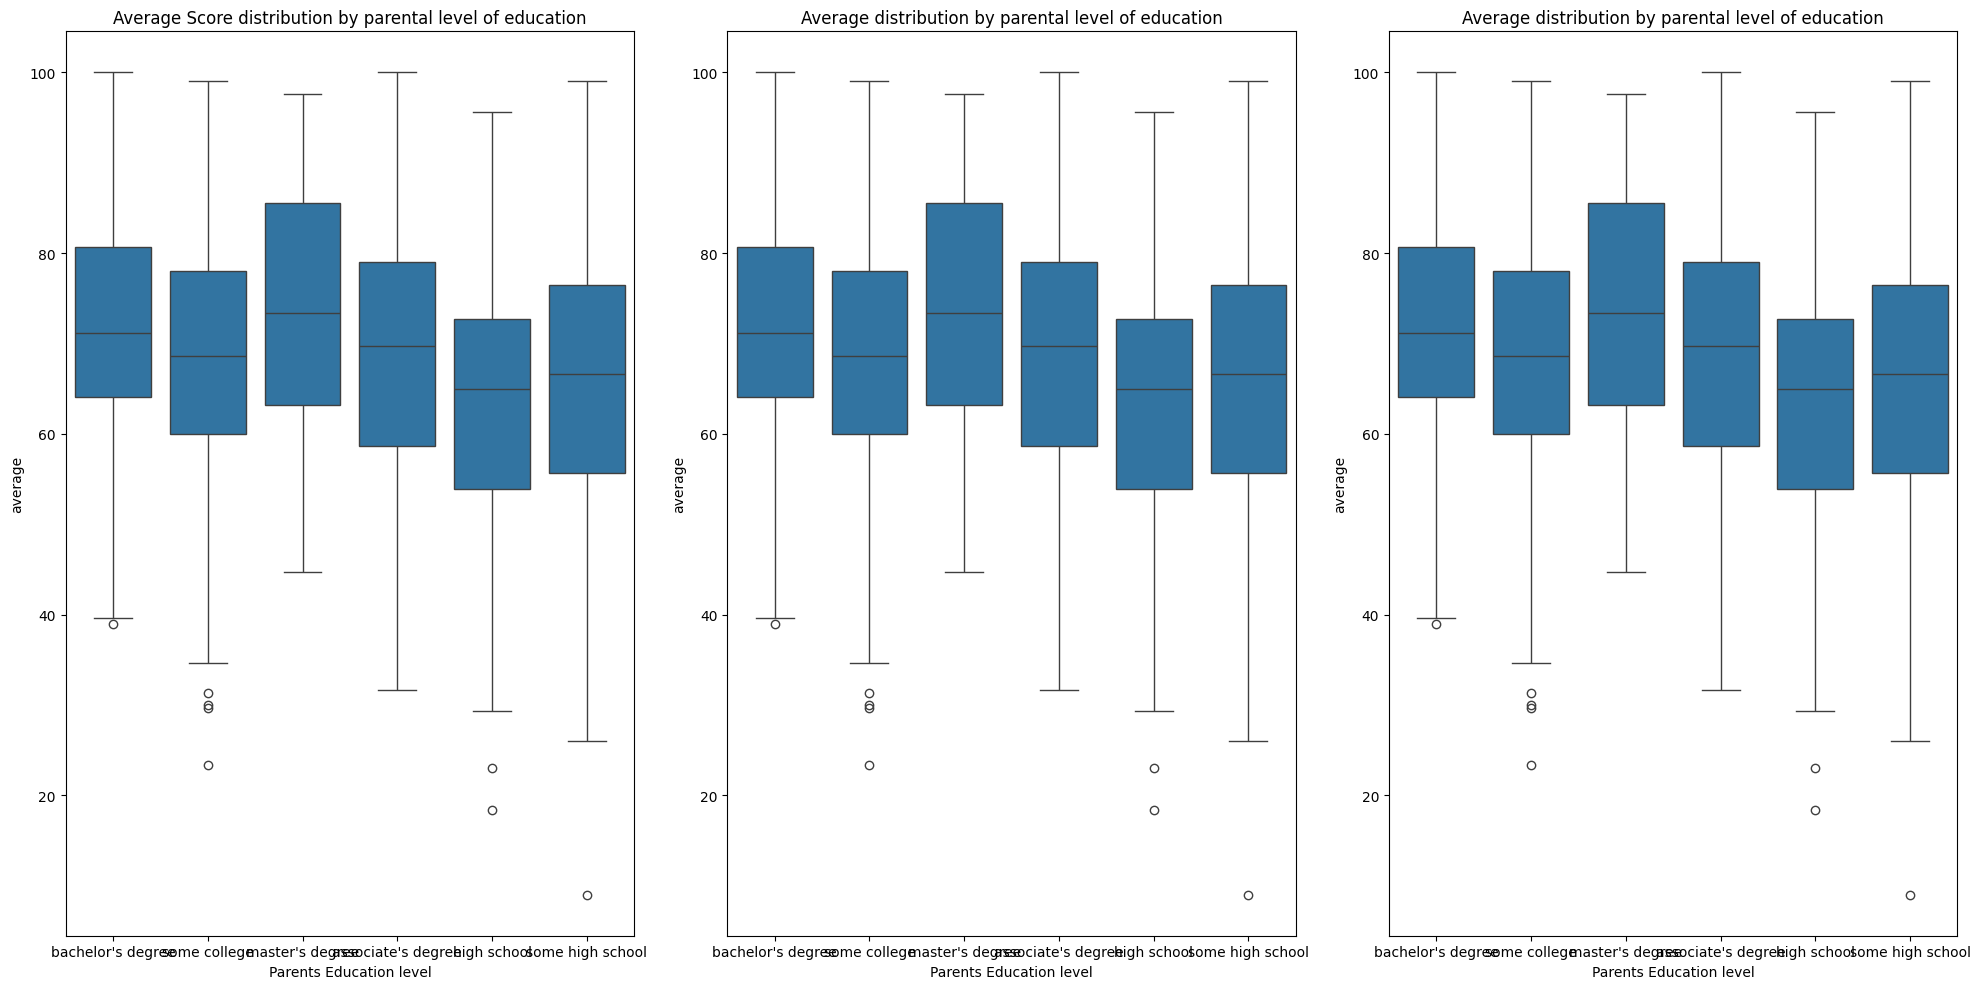

In [79]:
# To check for outliers in the data based on parental level of education.

fig,axs = plt.subplots(1,3,figsize=(20,10))

sns.boxplot (data = df, x = 'Parents Education level', y = 'average', ax=axs[0])
axs[0].set_title("Average Score distribution by parental level of education")

sns.boxplot (data = df, x = 'Parents Education level', y = 'average', ax=axs[1])
axs[1].set_title("Average distribution by parental level of education")

sns.boxplot (data = df, x = 'Parents Education level', y = 'average', ax=axs[2])
axs[2].set_title("Average distribution by parental level of education")

plt.tight_layout()
plt.show()


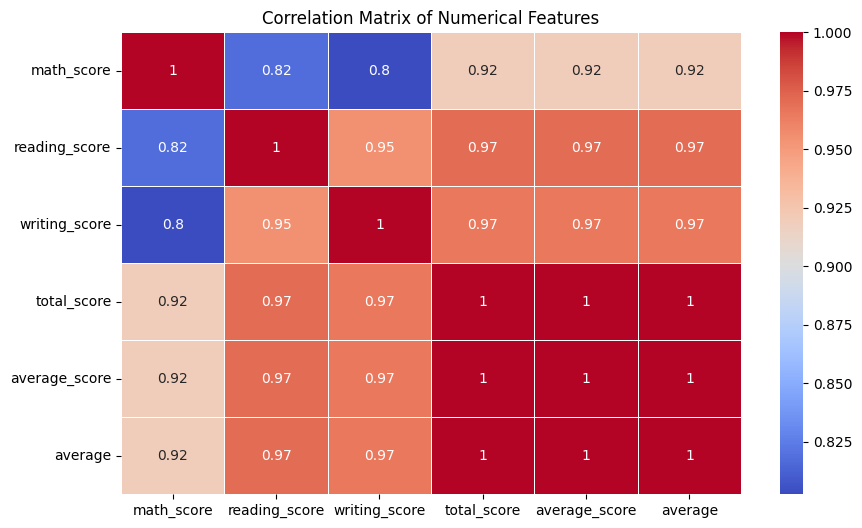

In [81]:
# Corelation between the numerical features in the dataset.

plt.figure(figsize=(10,6))  

corr_matrix = df.select_dtypes(include = ['int64','float64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()